In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("AB_NYC_2019.csv")

df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [8]:
#getting info from the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [10]:
# Checking for missing values
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [12]:
# Checking for the shape of the entire dataset
df.shape

(48895, 16)

In [20]:
# Filling the missing values of the reviews per month with 0 since these persons obviously have no reviews in a month
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [21]:
# Checking for the update after doing this
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [24]:
# Filling the missing values of last review with "No review" since it could be possible these persons didn't give any reviews
df['last_review'] = df['last_review'].fillna("No reviews")

In [28]:
# Replacing missing names and host names with "unknown" since names and host names are not really needed to analyse the data
df[['name', 'host_name']] = df[['name', 'host_name']].fillna("Unknown")

In [29]:
# Checking for the update after doing this
df.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

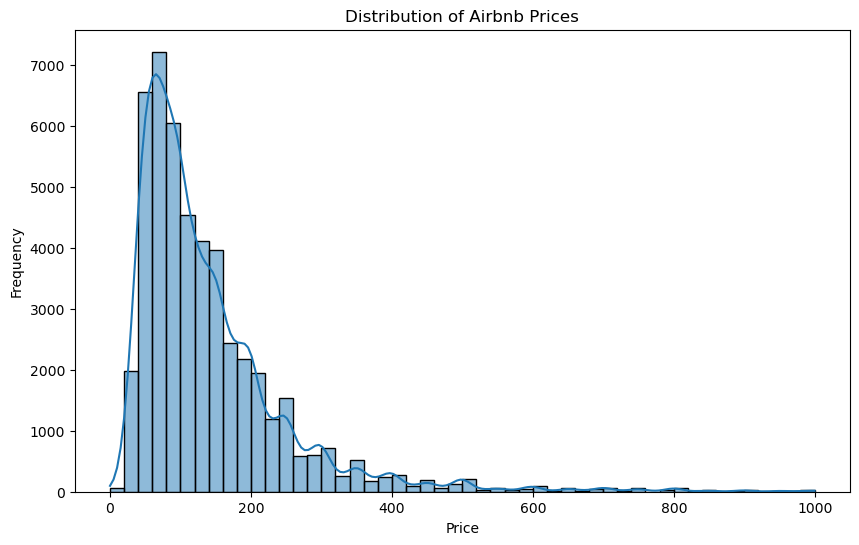

In [33]:
# Displaying the data on a histogram
plt.figure(figsize=(10,6))
sns.histplot(df[df['price'] < 1000]['price'], bins=50, kde=True)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

The distribution of Airbnb prices is positively skewed, with most listings concentrated between $50 and $200. The highest frequency of listings occurs around the $80–$120 range, indicating this as the most common price range. As prices increase, the number of listings decreases significantly, with only a few high-priced listings extending towards $1000. This suggests that the Airbnb market is dominated by affordable listings, with relatively few luxury options.

Add on: I removed outliers by displaying prices that are less than $1000

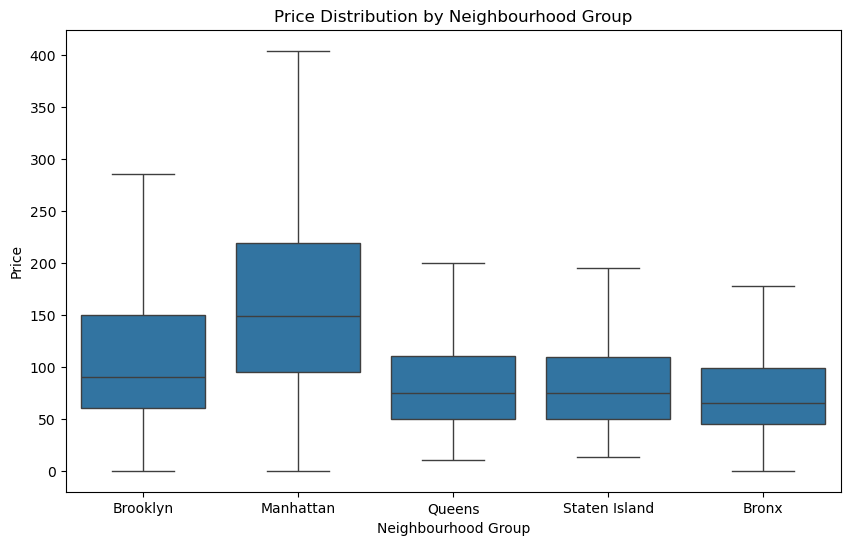

In [37]:
# Displaying the data on a boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='neighbourhood_group', y='price', data=df[df['price'] < 1000], showfliers=False)

plt.title("Price Distribution by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price")

plt.show()

The boxplot shows that Manhattan has the highest median price and the widest price range, confirming it as the most expensive and diverse Airbnb market. Brooklyn follows as the second most expensive area, with moderate variability in prices. In contrast, Queens, Staten Island, and the Bronx exhibit lower and more consistent price ranges, indicating more affordable and stable pricing structures. 

The removal of outliers provides a clearer view of typical pricing patterns across neighbourhoods.

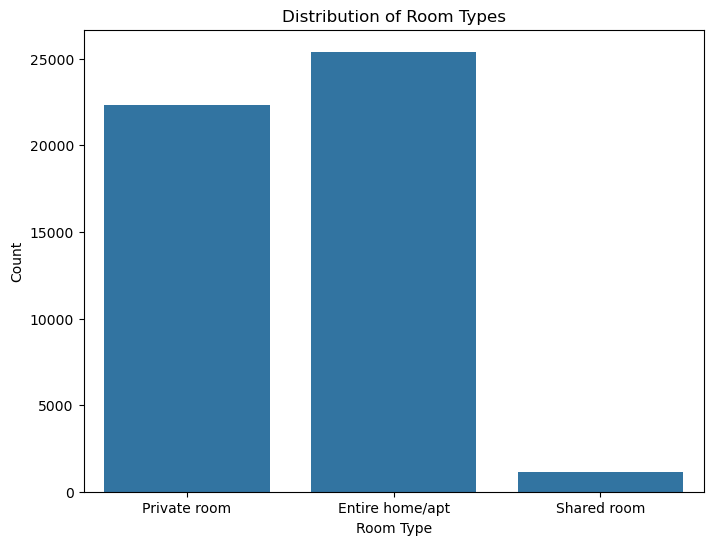

In [38]:
# Displaying the data on a countplot
plt.figure(figsize=(8,6))
sns.countplot(x='room_type', data=df)

plt.title("Distribution of Room Types")
plt.xlabel("Room Type")
plt.ylabel("Count")

plt.show()

This Countplot shows that more persons preferred the entire apartment than shared rooms which shows how much people love their privacy.